In [98]:
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras.applications.resnet50 import ResNet50
from keras.models import Model

In [99]:
data = ImageDataGenerator(rescale=1/255,
                          zoom_range=0.2,
                          rotation_range=40,)

In [100]:
path = 'datasets'
train_data = data.flow_from_directory(
    path,
    target_size=(64, 64),
    subset='training'
)

Found 3015 images belonging to 257 classes.


In [101]:
train_data.class_indices

{'aaron_taylor_johnson': 0,
 'abigail_breslin': 1,
 'adam_sandler': 2,
 'adrianne_palicki': 3,
 'alan_arkin': 4,
 'alec_baldwin': 5,
 'alexis_thorpe': 6,
 'amanda_seyfried': 7,
 'amy_adams': 8,
 'andrew_garfield': 9,
 'angelina_jolie': 10,
 'anjelica_huston': 11,
 'anna_kendrick': 12,
 'anna_paquin': 13,
 'annasophia_robb': 14,
 'anthony_hopkins': 15,
 'barbra_streisand': 16,
 'ben_affleck': 17,
 'ben_kingsley': 18,
 'ben_stiller': 19,
 'benedict_cumberbatch': 20,
 'bette_midler': 21,
 'betty_white': 22,
 'bill_murray': 23,
 'brad_pitt': 24,
 'bradley_cooper': 25,
 'brenda_fricker': 26,
 'bruce_willis': 27,
 'bryan_cranston': 28,
 'buster_keaton': 29,
 'cameron_diaz': 30,
 'carey_mulligan': 31,
 'carol_burnett': 32,
 'cary_grant': 33,
 'cate_blanchett': 34,
 'catherine_zeta_jones': 35,
 'channing_tatum': 36,
 'charlie_hunnam': 37,
 'charlize_theron': 38,
 'cher': 39,
 'chloe_grace_moretz': 40,
 'chris_cooper': 41,
 'chris_evans': 42,
 'chris_hemsworth': 43,
 'christian_bale': 44,
 'chr

In [102]:
# names = []
# for k,v in train_data.class_indices.items():
#     k = str(k).split('_')
#     k = ' '.join(k)
#     k = k.title()
#     names.append(k)
# print(names)

In [103]:
ResNet = ResNet50(input_shape=(64,64,3),include_top=False,weights="imagenet")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 84s 1us/step


In [104]:
def create_model():
    input = ResNet.output
    top_model = keras.layers.Flatten()(input)
    top_model = keras.layers.Dropout(0.4)(top_model)
    top_model = keras.layers.Dense(units=257,activation='softmax')(top_model)
    return top_model

In [105]:
model = Model(inputs=ResNet.inputs,outputs=create_model())

In [106]:
model.compile(optimizer='adam',loss=keras.losses.CategoricalCrossentropy(),metrics=['acc'])

In [107]:
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer_9[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 25,693,313 (98.01 MB)

 Trainable params: 25,640,193 (97.81 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [108]:
from keras.callbacks import EarlyStopping

In [109]:
# early = EarlyStopping('loss',patience=10)

In [110]:
hist = model.fit(train_data,epochs=100,batch_size=32,steps_per_epoch=50)

Epoch 1/100


c:\Users\Laptop Markazi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 727ms/step - acc: 0.0143 - loss: 7.7564
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 604ms/step - acc: 0.0231 - loss: 6.7426
Epoch 3/100


c:\Users\Laptop Markazi\AppData\Local\Programs\Python\Python310\lib\contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 716ms/step - acc: 0.0281 - loss: 6.1524
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 660ms/step - acc: 0.0454 - loss: 5.6294
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 726ms/step - acc: 0.0553 - loss: 5.3167
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 653ms/step - acc: 0.0478 - loss: 5.4513
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 740ms/step - acc: 0.0769 - loss: 5.0425
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 673ms/step - acc: 0.0867 - loss: 5.0060
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 753ms/step - acc: 0.0938 - loss: 4.7322
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 680ms/step - acc: 0.0745 - loss: 5.0211
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 763ms/step - acc: 0.1084 - loss: 4.6897
Epoch 12/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 680ms/step - acc: 0.1443 - loss: 4.4538
Epoch 13/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 739ms/step - acc: 0.1387 - loss: 4.1565
Epoch 14/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 666ms/step - acc: 0.1417 - loss: 4.4317
Epoch 15/10

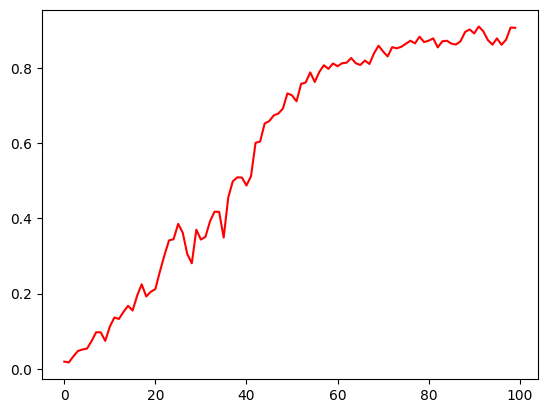

In [111]:
plt.plot(hist.history['acc'],color='r')
plt.show()

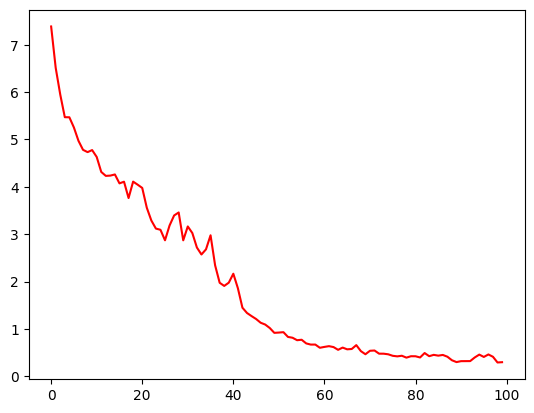

In [112]:
plt.plot(hist.history['loss'],color='r')
plt.show()

In [113]:
model.save('model.h5')